# NB11 · Route Feasibility Analysis

**Handoff notebook for NB12.** Builds route-level feasibility metrics for all 2,089 NB10 candidate-H3 coverage pairs.

## Key design decisions
| Decision | Choice |
|---|---|
| Route-pair source | `candidate_h3_coverage.parquet` (NB10) — NOT a cross-join |
| Drone-direct vs robot-handoff | **Separate independent modes** — drone feasibility does NOT require robot reachability |
| Airspace (approval scenario) | 관제권 intersection → flag only (`airspace_approval_required=True`), route remains feasible |
| Airspace (strict scenario) | 관제권 intersection → infeasible |
| DEM/slope raster | EPSG:5179 rasters sampled with EPSG:5179 route coordinates |
| Constraint exposure | Drone corridor (50 m buffer) intersected with `constraint_grid.gpkg` |

## Required inputs (`processed/`)
| File | Layer | Content |
|---|---|---|
| `final_candidate_sites.gpkg` | `final_candidate_sites` | 171 candidate lots |
| `candidate_h3_coverage.parquet` | — | 2,089 NB10 lot→H3 pairs |
| `delivery_zones.gpkg` | `delivery_zones` | H3 zone attributes + geometry |
| `constraint_grid.gpkg` | `constraint_grid` | H3 constraint scores |
| `seongnam_boundary.gpkg` | `dong` | Admin dong polygons |
| `seongnam_dem_b010.tif` | — | DEM, EPSG:5179 |
| `seongnam_slope_b010.tif` | — | Slope %, EPSG:5179 |
| `seongnam_walk_network.gpkg` | `edges`, `nodes` | OSM walk network |
| `airspace_constraint.gpkg` | `airspace_constraint` | 관제권 polygons |

## Outputs (`processed/nb11_*`)
| File | Content |
|---|---|
| `nb11_route_pairs.csv` | Full route-pair table (2,089 rows) |
| `nb11_route_analysis.gpkg` | Layers: `drone_routes`, `candidate_points`, `target_cells` |
| `nb11_candidate_route_summary.csv` | Lot-level aggregation + RFI |
| `nb11_route_map.html` | Interactive Folium map |
| `nb11_elevation_profiles.png` | Elevation profiles (3 representative routes) |
| `nb11_route_diagnostics.json` | Validation metrics for NB12 |


In [1]:
# ── CELL 1 · Imports & Constants ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import rasterio
from scipy.spatial import cKDTree
from shapely.geometry import LineString, Point
from shapely.ops import unary_union
from shapely.validation import make_valid
import matplotlib.pyplot as plt
import folium
from branca.colormap import linear as bl

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path(r'C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset')
PROC       = ROOT / 'processed'
CRS_PROJ   = 'EPSG:5179'

DEM_PATH   = PROC / 'seongnam_dem_b010.tif'
SLOPE_PATH = PROC / 'seongnam_slope_b010.tif'

# ── Physics / routing constants ───────────────────────────────────────────────
DRONE_SPEED_KMH    = 60
ROBOT_SPEED_KMH    = 4
DRONE_CORRIDOR_M   = 50
ROUTE_SAMPLE_PTS   = 30
SLOPE_PENALTY_BASE_DEG = 5.0   # degrees — slopes above this add robot travel time
SLOPE_PENALTY_RATE_DEG = 0.04  # fractional time added per 1 degree above base
ROBOT_CUTOFF_M     = 5000

print('✓ Imports and constants ready')
print(f'  Drone {DRONE_SPEED_KMH} km/h  |  Robot {ROBOT_SPEED_KMH} km/h')
print(f'  Corridor ±{DRONE_CORRIDOR_M} m  |  DEM sample pts {ROUTE_SAMPLE_PTS}')


✓ Imports and constants ready
  Drone 60 km/h  |  Robot 4 km/h
  Corridor ±50 m  |  DEM sample pts 30


In [2]:
# ── CELL 2 · Input Loading ────────────────────────────────────────────────────
def _gpkg(path, layer, required=True):
    p = Path(path)
    if not p.exists():
        if required:
            raise FileNotFoundError(f'REQUIRED file missing: {p}')
        print(f'  ⚠ optional missing: {p.name}')
        return None
    gdf = gpd.read_file(p, layer=layer)
    print(f'  ✓ {p.name} [{layer}] → {len(gdf)} rows, CRS={gdf.crs.to_epsg()}')
    return gdf

print('Loading inputs…')
sites_raw    = _gpkg(PROC / 'final_candidate_sites.gpkg',  'final_candidate_sites')
zones_gdf    = _gpkg(PROC / 'delivery_zones.gpkg',         'delivery_zones')
cgrid_gdf    = _gpkg(PROC / 'constraint_grid.gpkg',        'constraint_grid')
dong_gdf     = _gpkg(PROC / 'seongnam_boundary.gpkg',      'dong')
bnd_gdf      = _gpkg(PROC / 'seongnam_boundary.gpkg',      'city',    required=False)
net_edges    = _gpkg(PROC / 'seongnam_walk_network.gpkg',  'edges')
net_nodes    = _gpkg(PROC / 'seongnam_walk_network.gpkg',  'nodes')
airspace_gdf = _gpkg(PROC / 'airspace_constraint.gpkg',    'airspace_constraint', required=False)

# Coverage parquet (REQUIRED)
cov_path = PROC / 'candidate_h3_coverage.parquet'
if not cov_path.exists():
    raise FileNotFoundError(f'REQUIRED: {cov_path}')
coverage_df = pd.read_parquet(cov_path)
print(f'  ✓ candidate_h3_coverage.parquet → {len(coverage_df)} rows')
print(f'    cols: {list(coverage_df.columns)}')

# Rasters
HAS_DEM      = DEM_PATH.exists()
HAS_SLOPE    = SLOPE_PATH.exists()
HAS_AIRSPACE = airspace_gdf is not None and len(airspace_gdf) > 0
HAS_NETWORK  = net_edges is not None and net_nodes is not None

for label, path, ok in [('DEM', DEM_PATH, HAS_DEM), ('Slope', SLOPE_PATH, HAS_SLOPE)]:
    if ok:
        with rasterio.open(path) as src:
            print(f'  ✓ {path.name}: CRS={src.crs.to_epsg()}, nodata={src.nodata}')
    else:
        print(f'  ⚠ {label} raster missing: {path.name}')

print(f'\nFlags: HAS_DEM={HAS_DEM} | HAS_SLOPE={HAS_SLOPE} | HAS_AIRSPACE={HAS_AIRSPACE} | HAS_NETWORK={HAS_NETWORK}')

Loading inputs…
  ✓ final_candidate_sites.gpkg [final_candidate_sites] → 171 rows, CRS=4326
  ✓ delivery_zones.gpkg [delivery_zones] → 1947 rows, CRS=4326
  ✓ constraint_grid.gpkg [constraint_grid] → 1947 rows, CRS=4326
  ✓ seongnam_boundary.gpkg [dong] → 50 rows, CRS=4326
  ✓ seongnam_boundary.gpkg [city] → 1 rows, CRS=4326


  ✓ seongnam_walk_network.gpkg [edges] → 54840 rows, CRS=4326
  ✓ seongnam_walk_network.gpkg [nodes] → 19271 rows, CRS=4326
  ✓ airspace_constraint.gpkg [airspace_constraint] → 2 rows, CRS=5179
  ✓ candidate_h3_coverage.parquet → 9793 rows
    cols: ['lot_id', 'h3_index', 'ADM_NM', 'GU_NM', 'Ds', 'demand_grade', 'delivery_zone', 'service_priority_score', 'constraint_score', 'distance_to_lot_m', 'lot_name']
  ✓ seongnam_dem_b010.tif: CRS=5179, nodata=nan
  ✓ seongnam_slope_b010.tif: CRS=5179, nodata=nan

Flags: HAS_DEM=True | HAS_SLOPE=True | HAS_AIRSPACE=True | HAS_NETWORK=True


In [3]:
# ── CELL 3 · Build Route-Pair Table from NB10 Coverage ───────────────────────
# Start from coverage (2,089 rows). DO NOT cross-join.

pairs = coverage_df.copy()
EXPECTED_N = len(coverage_df)

# Rename coverage columns to distinguish target-zone vs site
pairs = pairs.rename(columns={
    'h3_index': 'target_h3_index',
    'ADM_NM':   'target_ADM_NM',
    'GU_NM':    'target_GU_NM',
})
pairs['within_1km_centroid'] = pairs['distance_to_lot_m'] <= 1000

# ── Join candidate attributes from final_candidate_sites ─────────────────────
SITE_COLS = [
    'lot_id', 'lat', 'lon',
    'candidate_rank', 'candidate_grade', 'candidate_score_for_ranking',
    'parking_site_score', 'demand_context_score', 'constraint_context_score',
    'airspace_review_required',
    # NB10 dong-join result — we'll rename to site_* after merge
    'ADM_NM', 'GU_NM', 'CSV_ADMI_CD',
]
site_join = sites_raw[[c for c in SITE_COLS if c in sites_raw.columns]].copy()

# coverage already has lot_name; keep it.  Merge on lot_id only.
pairs = pairs.merge(site_join, on='lot_id', how='left')

# Rename NB10 site admin cols to site_* (temporary — will be overwritten by dong sjoin in Cell 4)
pairs = pairs.rename(columns={
    'ADM_NM':    'site_ADM_NM',
    'GU_NM':     'site_GU_NM',
    'CSV_ADMI_CD': 'site_CSV_ADMI_CD',
})

# ── Join zone attributes from delivery_zones (by target_h3_index) ─────────────
ZONE_ADD_COLS = [
    'h3_index', 'lat', 'lon',   # zone centroid
    'score_airspace', 'score_obstacle', 'score_noise_proxy',
    'score_terrain', 'score_robot', 'score_weather',
    'hard_exclusion_flag', 'drone_score', 'robot_score',
    'high_demand_flag', 'priority_zone',
    'airspace_proxy_flag', 'airspace_proxy_caution_flag',
]
zone_join = zones_gdf[[c for c in ZONE_ADD_COLS if c in zones_gdf.columns]].copy()
zone_join = zone_join.rename(columns={'lat': 'target_lat', 'lon': 'target_lon'})
pairs = pairs.merge(
    zone_join,
    left_on='target_h3_index', right_on='h3_index', how='left'
).drop(columns=['h3_index'], errors='ignore')

# ── Join constraint_grid extras (by target_h3_index) ─────────────────────────
CGRID_ADD_COLS = ['h3_index', 'n_highrise', 'weather_risk', 'Ra', 'n_crossings', 'n_buildings_total']
cgrid_join = cgrid_gdf[[c for c in CGRID_ADD_COLS if c in cgrid_gdf.columns]].copy()
pairs = pairs.merge(
    cgrid_join,
    left_on='target_h3_index', right_on='h3_index', how='left'
).drop(columns=['h3_index'], errors='ignore')

assert len(pairs) == EXPECTED_N, f'Row count drifted: {len(pairs)} ≠ {EXPECTED_N}'
print(f'✓ Route-pair table: {len(pairs)} rows × {pairs.shape[1]} cols')
print(f'  Unique lot_id:          {pairs["lot_id"].nunique()}')
print(f'  Unique target_h3_index: {pairs["target_h3_index"].nunique()}')
print(f'  within_1km_centroid:    {pairs["within_1km_centroid"].sum()}')

✓ Route-pair table: 9793 rows × 44 cols
  Unique lot_id:          171
  Unique target_h3_index: 1106
  within_1km_centroid:    7246


In [4]:
# ── CELL 4 · Site Administrative Labels (Spatial Join to Dong) ────────────────
# Fresh sjoin overwrites the NB10-sourced site_ADM_NM/GU_NM with authoritative values.

# Project to 5179 for accuracy
sites_5179 = sites_raw[['lot_id', 'geometry']].copy()
if sites_5179.crs.to_epsg() != 5179:
    sites_5179 = sites_5179.to_crs(CRS_PROJ)

dong_5179 = dong_gdf[['ADM_NM', 'GU_NM', 'CSV_ADMI_CD', 'geometry']].copy()
if dong_5179.crs.to_epsg() != 5179:
    dong_5179 = dong_5179.to_crs(CRS_PROJ)
dong_5179 = dong_5179.rename(columns={
    'ADM_NM':    '_d_ADM_NM',
    'GU_NM':     '_d_GU_NM',
    'CSV_ADMI_CD': '_d_CSV',
})

site_dong = gpd.sjoin(sites_5179, dong_5179, how='left', predicate='within')
site_dong = site_dong.drop_duplicates(subset='lot_id', keep='first')
site_dong = site_dong[['lot_id', '_d_ADM_NM', '_d_GU_NM', '_d_CSV']].rename(columns={
    '_d_ADM_NM': 'site_ADM_NM',
    '_d_GU_NM':  'site_GU_NM',
    '_d_CSV':    'site_CSV_ADMI_CD',
})

# Fallback for any sites that fell outside all dong polygons (boundary edge cases)
null_mask = site_dong['site_ADM_NM'].isna()
if null_mask.any():
    print(f'  ⚠ {null_mask.sum()} sites missed sjoin — falling back to NB10 values')
    nb10_vals = sites_raw[['lot_id', 'ADM_NM', 'GU_NM', 'CSV_ADMI_CD']].set_index('lot_id')
    sd = site_dong.set_index('lot_id')
    sd.loc[sd['site_ADM_NM'].isna(), 'site_ADM_NM']    = nb10_vals.loc[sd['site_ADM_NM'].isna().index, 'ADM_NM']
    sd.loc[sd['site_GU_NM'].isna(),  'site_GU_NM']     = nb10_vals.loc[sd['site_GU_NM'].isna().index,  'GU_NM']
    sd.loc[sd['site_CSV_ADMI_CD'].isna(), 'site_CSV_ADMI_CD'] = nb10_vals.loc[sd['site_CSV_ADMI_CD'].isna().index, 'CSV_ADMI_CD']
    site_dong = sd.reset_index()

# Replace old NB10-sourced site_* cols in pairs with fresh sjoin result
pairs = pairs.drop(columns=['site_ADM_NM', 'site_GU_NM', 'site_CSV_ADMI_CD'], errors='ignore')
pairs = pairs.merge(site_dong, on='lot_id', how='left')

# Validate
null_adm = int(pairs['site_ADM_NM'].isna().sum())
null_gu  = int(pairs['site_GU_NM'].isna().sum())
null_csv = int(pairs['site_CSV_ADMI_CD'].isna().sum())
print(f'✓ Site admin labels: site_ADM_NM nulls={null_adm}, site_GU_NM nulls={null_gu}, site_CSV nulls={null_csv}')
assert null_adm == 0, f'site_ADM_NM still has {null_adm} nulls'
assert null_gu  == 0, f'site_GU_NM still has {null_gu} nulls'

✓ Site admin labels: site_ADM_NM nulls=0, site_GU_NM nulls=0, site_CSV nulls=0


In [5]:
# ── CELL 5 · Drone Route Geometry & Travel Time ───────────────────────────────

# Candidate lot point geometries (EPSG:5179)
sites_5179_pts = sites_raw[['lot_id', 'geometry']].copy()
if sites_5179_pts.crs.to_epsg() != 5179:
    sites_5179_pts = sites_5179_pts.to_crs(CRS_PROJ)
lot_pt_map = dict(zip(sites_5179_pts['lot_id'], sites_5179_pts.geometry))

# Target H3 centroid geometries (EPSG:5179)
zones_5179 = zones_gdf[['h3_index', 'geometry']].copy()
if zones_5179.crs.to_epsg() != 5179:
    zones_5179 = zones_5179.to_crs(CRS_PROJ)
zone_centroid_map = dict(zip(zones_5179['h3_index'], zones_5179.geometry.centroid))

# Verify all target H3 indexes exist in zones
missing_h3 = set(pairs['target_h3_index'].unique()) - set(zone_centroid_map.keys())
if missing_h3:
    print(f'  ⚠ {len(missing_h3)} target H3 cells not found in delivery_zones — routes will be null')

# Build drone lines (EPSG:5179 straight-line)
def _make_drone_line(lot_id, h3_idx):
    a = lot_pt_map.get(lot_id)
    b = zone_centroid_map.get(h3_idx)
    if a is None or b is None:
        return None
    try:
        if a.distance(b) < 1:
            return None
        return LineString([a, b])
    except Exception:
        return None

pairs['drone_line'] = [
    _make_drone_line(r.lot_id, r.target_h3_index)
    for r in pairs.itertuples()
]

pairs['drone_distance_m'] = pairs['drone_line'].apply(lambda g: g.length if g else np.nan)
drone_mpm = DRONE_SPEED_KMH * 1000 / 60
pairs['drone_time_min'] = pairs['drone_distance_m'] / drone_mpm

# 50-m corridor buffer used for airspace & constraint-grid checks (dropped after Cell 8)
pairs['_corridor'] = pairs['drone_line'].apply(
    lambda g: g.buffer(DRONE_CORRIDOR_M) if g else None
)

n_valid = int(pairs['drone_line'].notna().sum())
print(f'✓ Drone routes: {n_valid}/{len(pairs)} valid')
d = pairs['drone_distance_m'].dropna()
print(f'  Distance: {d.min():.0f}–{d.max():.0f} m  mean={d.mean():.0f} m')
t = pairs['drone_time_min'].dropna()
print(f'  Time:     {t.min():.1f}–{t.max():.1f} min  mean={t.mean():.1f} min')

✓ Drone routes: 9793/9793 valid
  Distance: 14–1180 m  mean=772 m
  Time:     0.0–1.2 min  mean=0.8 min


In [6]:
# ?? CELL 6 ? DEM & Slope Raster Sampling ?????????????????????????????????????
# Rasters are EPSG:5179. drone_line is EPSG:5179. No CRS transform needed.
# NB03b writes seongnam_slope_b010.tif in degrees, so all slope columns use *_deg.

def _sample_src(line, src, n):
    """Sample an open rasterio dataset at n points along a LineString."""
    if line is None or line.length < 1:
        return np.full(n, np.nan)
    dists  = np.linspace(0, line.length, n)
    coords = [(line.interpolate(d).x, line.interpolate(d).y) for d in dists]
    vals   = np.array([v[0] for v in src.sample(coords)], dtype=float)
    if src.nodata is not None:
        vals[vals == src.nodata] = np.nan
    return vals

def _metrics(dem_vals, slope_vals, line_length_m=None):
    v = dem_vals[~np.isnan(dem_vals)]
    if len(v) < 2:
        return dict(elev_min_m=np.nan, elev_max_m=np.nan, elev_gain_m=np.nan,
                    mean_slope_deg=np.nan, max_slope_deg=np.nan)
    if slope_vals is not None:
        sv = slope_vals[~np.isnan(slope_vals)]
        ms = float(np.mean(sv)) if len(sv) > 0 else np.nan
        xs = float(np.max(sv))  if len(sv) > 0 else np.nan
    else:
        # Only if no slope raster: infer approximate degrees from DEM differences.
        if line_length_m and line_length_m > 0 and len(v) > 1:
            dx = line_length_m / (len(v) - 1)
            sv = np.degrees(np.arctan(np.abs(np.diff(v)) / dx))
        else:
            sv = np.array([], dtype=float)
        ms = float(np.mean(sv)) if len(sv) > 0 else np.nan
        xs = float(np.max(sv))  if len(sv) > 0 else np.nan
    return dict(
        elev_min_m=float(np.min(v)), elev_max_m=float(np.max(v)),
        elev_gain_m=float(np.max(v) - np.min(v)),
        mean_slope_deg=ms, max_slope_deg=xs,
    )

print(f'Sampling rasters ({ROUTE_SAMPLE_PTS} pts ? {len(pairs)} routes)?')
elev_records = []

dem_ctx   = rasterio.open(DEM_PATH)   if HAS_DEM   else None
slope_ctx = rasterio.open(SLOPE_PATH) if HAS_SLOPE else None
try:
    for line in pairs['drone_line']:
        dv = _sample_src(line, dem_ctx,   ROUTE_SAMPLE_PTS) if dem_ctx   else np.full(ROUTE_SAMPLE_PTS, np.nan)
        sv = _sample_src(line, slope_ctx, ROUTE_SAMPLE_PTS) if slope_ctx else None
        elev_records.append(_metrics(dv, sv, line.length if line else None))
finally:
    if dem_ctx:   dem_ctx.close()
    if slope_ctx: slope_ctx.close()

elev_df = pd.DataFrame(elev_records)
for col in elev_df.columns:
    pairs[col] = elev_df[col].values

nn_elev  = int(pairs['elev_min_m'].notna().sum())
nn_slope = int(pairs['mean_slope_deg'].notna().sum())
print(f'? DEM/slope sampling complete')
print(f'  elev_min_m non-null    : {nn_elev}/{len(pairs)}')
print(f'  mean_slope_deg non-null: {nn_slope}/{len(pairs)}')
if nn_elev > 0:
    print(f'  Elevation gain: {pairs["elev_gain_m"].min():.1f}?{pairs["elev_gain_m"].max():.1f} m')
    print(f'  Mean slope:     {pairs["mean_slope_deg"].min():.2f}?{pairs["mean_slope_deg"].max():.2f}?')
assert nn_elev > 0 or not HAS_DEM, 'DEM raster found but all elevation values are null'


Sampling rasters (30 pts ? 9793 routes)?


? DEM/slope sampling complete
  elev_min_m non-null    : 9793/9793
  mean_slope_deg non-null: 9793/9793
  Elevation gain: 0.1?344.1 m
  Mean slope:     0.11?28.65?


In [7]:
# ?? CELL 7 ? Constraint-Grid Corridor Scoring ?????????????????????????????????
# Intersect each drone corridor with constraint_grid cells (in EPSG:5179).
# NB09's hard_exclusion_flag currently mirrors ???/score_airspace in many cells.
# For NB11 we split airspace review from true non-airspace blockers.

cgrid_5179 = cgrid_gdf.copy()
if cgrid_5179.crs.to_epsg() != 5179:
    cgrid_5179 = cgrid_5179.to_crs(CRS_PROJ)
cgrid_5179['geometry'] = cgrid_5179.geometry.apply(make_valid)
cgrid_sidx = cgrid_5179.sindex

def _bool_series(s):
    """Parse bool-like columns robustly, including GPKG text values 'True'/'False'."""
    txt = s.fillna(False).astype(str).str.strip().str.lower()
    num = pd.to_numeric(s, errors='coerce')
    return txt.isin(['true', 't', 'yes', 'y', '1']) | (num == 1)

def _corr_metrics(corridor):
    null = dict(
        route_crossed_h3_count=0,
        route_mean_constraint_score=np.nan,
        route_min_constraint_score=np.nan,
        route_mean_drone_score=np.nan,
        route_mean_robot_score=np.nan,
        route_highrise_cell_count=0,
        route_max_weather_risk=np.nan,
        route_crosses_airspace_exclusion=False,
        route_crosses_non_airspace_hard_exclusion=False,
        route_crosses_hard_exclusion=False,  # compatibility alias = non-airspace hard exclusion
    )
    if corridor is None:
        return null
    try:
        cands = list(cgrid_sidx.intersection(corridor.bounds))
        if not cands:
            return null
        hits = cgrid_5179.iloc[cands]
        hits = hits[hits.intersects(corridor)]
        if len(hits) == 0:
            return null

        def _col_mean(c):  return float(hits[c].mean()) if c in hits.columns else np.nan
        def _col_min(c):   return float(hits[c].min())  if c in hits.columns else np.nan
        def _col_max(c):   return float(hits[c].max())  if c in hits.columns else np.nan
        def _col_gt0(c):   return int((hits[c] > 0).sum()) if c in hits.columns else 0

        if 'score_airspace' in hits.columns:
            airspace_cells = hits['score_airspace'].fillna(1.0).astype(float) <= 0.0
        else:
            airspace_cells = pd.Series(False, index=hits.index)

        if 'hard_exclusion_flag' in hits.columns:
            hard_cells = _bool_series(hits['hard_exclusion_flag'])
        else:
            hard_cells = pd.Series(False, index=hits.index)

        airspace_hit = bool(airspace_cells.any())
        non_airspace_hard = bool((hard_cells & ~airspace_cells).any())

        return dict(
            route_crossed_h3_count=len(hits),
            route_mean_constraint_score=_col_mean('constraint_score'),
            route_min_constraint_score=_col_min('constraint_score'),
            route_mean_drone_score=_col_mean('drone_score'),
            route_mean_robot_score=_col_mean('robot_score'),
            route_highrise_cell_count=_col_gt0('n_highrise'),
            route_max_weather_risk=_col_max('weather_risk'),
            route_crosses_airspace_exclusion=airspace_hit,
            route_crosses_non_airspace_hard_exclusion=non_airspace_hard,
            route_crosses_hard_exclusion=non_airspace_hard,
        )
    except Exception:
        return null

print(f'Scoring {len(pairs)} route corridors against {len(cgrid_5179)} grid cells?')
corr_df = pd.DataFrame([_corr_metrics(c) for c in pairs['_corridor']])
for col in corr_df.columns:
    pairs[col] = corr_df[col].values

# Fallback: routes crossing 0 cells ? use target H3 attributes
no_cross = pairs['route_crossed_h3_count'] == 0
for src_col, dst_col in [
    ('constraint_score', 'route_mean_constraint_score'),
    ('constraint_score', 'route_min_constraint_score'),
    ('drone_score',      'route_mean_drone_score'),
    ('robot_score',      'route_mean_robot_score'),
    ('weather_risk',     'route_max_weather_risk'),
]:
    if src_col in pairs.columns and dst_col in pairs.columns:
        pairs.loc[no_cross, dst_col] = pairs.loc[no_cross, src_col]
if 'n_highrise' in pairs.columns:
    pairs.loc[no_cross, 'route_highrise_cell_count'] = pairs.loc[no_cross, 'n_highrise'].fillna(0).astype(int)
if 'score_airspace' in pairs.columns:
    pairs.loc[no_cross, 'route_crosses_airspace_exclusion'] = pairs.loc[no_cross, 'score_airspace'].fillna(1.0).astype(float) <= 0.0
if 'hard_exclusion_flag' in pairs.columns:
    hard = _bool_series(pairs.loc[no_cross, 'hard_exclusion_flag'])
    air = pairs.loc[no_cross, 'route_crosses_airspace_exclusion'].fillna(False).astype(bool)
    pairs.loc[no_cross, 'route_crosses_non_airspace_hard_exclusion'] = hard & ~air
    pairs.loc[no_cross, 'route_crosses_hard_exclusion'] = hard & ~air

print(f'? Constraint corridor scoring complete')
print(f'  Routes crossing ?1 cell              : {(pairs["route_crossed_h3_count"] > 0).sum()}')
print(f'  Routes with no cross (fallback)      : {no_cross.sum()}')
print(f'  Routes crossing airspace review cells: {pairs["route_crosses_airspace_exclusion"].sum()}')
print(f'  Routes crossing non-air hard blockers: {pairs["route_crosses_non_airspace_hard_exclusion"].sum()}')
print(f'  mean_route_constraint_score          : {pairs["route_mean_constraint_score"].mean():.4f}')
nn_corr = int(pairs['route_mean_constraint_score'].notna().sum())
print(f'  route_mean_constraint_score non-null : {nn_corr}/{len(pairs)}')


Scoring 9793 route corridors against 1947 grid cells?


? Constraint corridor scoring complete
  Routes crossing ?1 cell              : 9793
  Routes with no cross (fallback)      : 0
  Routes crossing airspace review cells: 9585
  Routes crossing non-air hard blockers: 0
  mean_route_constraint_score          : 0.6727
  route_mean_constraint_score non-null : 9793/9793


In [8]:
# ?? CELL 8 ? Airspace Handling ????????????????????????????????????????????????
# Dissolve ??? polygons ? one predicate call per corridor.
# approval scenario : intersection ? flag only (route still feasible)
# strict scenario   : intersection ? excluded

if HAS_AIRSPACE:
    print(f'Dissolving {len(airspace_gdf)} airspace polygon(s)?')
    air_5179 = airspace_gdf.copy()
    if air_5179.crs.to_epsg() != 5179:
        air_5179 = air_5179.to_crs(CRS_PROJ)
    air_union = unary_union(air_5179.geometry.apply(make_valid).values)
    print(f'  ??? union area: {air_union.area / 1e6:.2f} km?')

    def _hits_air(corr):
        if corr is None:
            return False
        try:
            return bool(corr.intersects(air_union))
        except Exception:
            return False

    airspace_from_polygon = pd.Series([_hits_air(c) for c in pairs['_corridor']], index=pairs.index)
    n_air_poly = int(airspace_from_polygon.sum())
    print(f'? Airspace polygon check: {n_air_poly}/{len(pairs)} routes intersect ??? polygon')
else:
    print('? No airspace data ? polygon airspace flag False for all routes')
    airspace_from_polygon = pd.Series(False, index=pairs.index)

# Union the official polygon check with the constraint-grid airspace signal.
# This keeps approval-required conservative without treating it as a hard blocker.
pairs['airspace_approval_required'] = (
    airspace_from_polygon.astype(bool)
    | pairs.get('route_crosses_airspace_exclusion', pd.Series(False, index=pairs.index)).fillna(False).astype(bool)
)
pairs['strict_airspace_excluded'] = pairs['airspace_approval_required']

n_air = int(pairs['airspace_approval_required'].sum())
print(f'  Combined airspace approval flag: {n_air}/{len(pairs)} routes')

# Drop corridor column ? no longer needed
pairs = pairs.drop(columns=['_corridor'], errors='ignore')


Dissolving 2 airspace polygon(s)?
  ??? union area: 120.77 km?
? Airspace polygon check: 9572/9793 routes intersect ??? polygon
  Combined airspace approval flag: 9585/9793 routes


In [9]:
# ── CELL 9 · Robot-Handoff Routing (NetworkX, Single-Source Dijkstra) ─────────
# Independent mode — robot feasibility does NOT affect drone feasibility.

if HAS_NETWORK:
    print('Building NetworkX graph from OSM walk network…')

    # Project nodes to EPSG:5179 for accurate nearest-node snapping
    nodes_5179 = net_nodes.copy()
    if nodes_5179.crs.to_epsg() != 5179:
        nodes_5179 = nodes_5179.to_crs(CRS_PROJ)

    node_ids = nodes_5179['osmid'].values
    node_xy  = np.array([(g.x, g.y) for g in nodes_5179.geometry])
    kd       = cKDTree(node_xy)

    G = nx.Graph()
    for nid, (x, y) in zip(node_ids, node_xy):
        G.add_node(nid, x=x, y=y)
    for row in net_edges.itertuples(index=False):
        G.add_edge(row.u, row.v, length=float(row.length))

    print(f'  Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

    def _snap(pt):
        _, idx = kd.query([pt.x, pt.y])
        return node_ids[idx]

    # Snap unique lot centroids once
    lot_node_map = {
        lid: _snap(pt)
        for lid, pt in lot_pt_map.items()
    }

    # Single-source Dijkstra — one run per lot (171 total)
    print(f'Running single-source Dijkstra for {len(lot_node_map)} lots…')
    lot_dist_map = {
        lid: nx.single_source_dijkstra_path_length(
            G, src_node, cutoff=ROBOT_CUTOFF_M, weight='length'
        )
        for lid, src_node in lot_node_map.items()
    }

    # Snap unique target H3 centroids once (cache per h3_index)
    zone_node_map = {
        h3: _snap(centroid)
        for h3, centroid in zone_centroid_map.items()
    }

    def _robot_dist(lot_id, h3_idx):
        dists  = lot_dist_map.get(lot_id, {})
        d_node = zone_node_map.get(h3_idx)
        if d_node is None:
            return np.nan
        return dists.get(d_node, np.nan)

    pairs['robot_distance_m'] = [
        _robot_dist(r.lot_id, r.target_h3_index) for r in pairs.itertuples()
    ]
    pairs['robot_path_found'] = (
        pairs['robot_distance_m'].notna() & (pairs['robot_distance_m'] <= ROBOT_CUTOFF_M)
    )
    USE_NETWORK = True
    print(f'✓ Dijkstra complete')

else:
    print('⚠ Network not available — Euclidean × 1.35 fallback')
    pairs['robot_distance_m'] = pairs['drone_distance_m'] * 1.35
    pairs['robot_path_found'] = pairs['robot_distance_m'] <= ROBOT_CUTOFF_M
    USE_NETWORK = False

# Slope-adjusted travel time
robot_mpm    = ROBOT_SPEED_KMH * 1000 / 60
base_time    = pairs['robot_distance_m'] / robot_mpm
excess_slope = (pairs['mean_slope_deg'].fillna(0) - SLOPE_PENALTY_BASE_DEG).clip(lower=0)
slope_factor = 1.0 + excess_slope * SLOPE_PENALTY_RATE_DEG

pairs['robot_time_min']          = base_time
pairs['robot_time_min_adjusted'] = base_time * slope_factor
pairs['robot_handoff_feasible']  = pairs['robot_path_found']

n_found = int(pairs['robot_path_found'].sum())
rd = pairs['robot_distance_m'].dropna()
print(f'  robot_path_found: {n_found}/{len(pairs)} ({n_found/len(pairs)*100:.1f}%)')
if len(rd) > 0:
    print(f'  Distance: {rd.min():.0f}–{rd.max():.0f} m  mean={rd.mean():.0f} m')


Building NetworkX graph from OSM walk network…


  Graph: 19,271 nodes, 27,019 edges
Running single-source Dijkstra for 171 lots…


✓ Dijkstra complete
  robot_path_found: 9765/9793 (99.7%)
  Distance: 0–4979 m  mean=1176 m


In [10]:
# ?? CELL 10 ? Feasibility Classification ?????????????????????????????????????
# Drone-direct and robot-handoff are INDEPENDENT modes.
# Drone feasibility does NOT require robot reachability.

valid_drone_route = pairs['drone_line'].notna()
non_air_hard = pairs['route_crosses_non_airspace_hard_exclusion'].fillna(False).astype(bool)
airspace_review = pairs['airspace_approval_required'].fillna(False).astype(bool)

# Approval scenario: ??? is a permit/review flag, not an infeasibility condition.
pairs['drone_direct_feasible_approval'] = valid_drone_route & ~non_air_hard

# Strict scenario: same valid route, but ??? blocks the route.
pairs['drone_direct_feasible_strict'] = (
    pairs['drone_direct_feasible_approval']
    & ~airspace_review
)

# Robot-handoff (already set in Cell 9, re-assert for clarity)
pairs['robot_handoff_feasible'] = pairs['robot_path_found'].astype(bool)

n_app   = int(pairs['drone_direct_feasible_approval'].sum())
n_str   = int(pairs['drone_direct_feasible_strict'].sum())
n_robot = int(pairs['robot_handoff_feasible'].sum())
n_air   = int(pairs['airspace_approval_required'].sum())
n_nonair_hard = int(pairs['route_crosses_non_airspace_hard_exclusion'].sum())

print('? Feasibility classification')
print(f'  drone_direct_feasible_approval : {n_app}/{len(pairs)} ({n_app/len(pairs)*100:.1f}%)')
print(f'  drone_direct_feasible_strict   : {n_str}/{len(pairs)} ({n_str/len(pairs)*100:.1f}%)')
print(f'  robot_handoff_feasible         : {n_robot}/{len(pairs)} ({n_robot/len(pairs)*100:.1f}%)')
print(f'  airspace_approval_required     : {n_air}/{len(pairs)} ({n_air/len(pairs)*100:.1f}%)')
print(f'  non_airspace_hard_exclusion    : {n_nonair_hard}/{len(pairs)} ({n_nonair_hard/len(pairs)*100:.1f}%)')
assert n_app > 0, 'Approval scenario has zero feasible drone routes ? check hard-exclusion logic'
assert n_str <= n_app, f'strict ({n_str}) > approval ({n_app}) ? logic error'


? Feasibility classification
  drone_direct_feasible_approval : 9793/9793 (100.0%)
  drone_direct_feasible_strict   : 208/9793 (2.1%)
  robot_handoff_feasible         : 9765/9793 (99.7%)
  airspace_approval_required     : 9585/9793 (97.9%)
  non_airspace_hard_exclusion    : 0/9793 (0.0%)


In [11]:
# ── CELL 11 · Candidate-Level Aggregation & Route Feasibility Index ───────────

def _minmax(s, invert=False):
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(0.5, index=s.index)
    n = (s - mn) / (mx - mn)
    return 1.0 - n if invert else n

rows = []
for lid, g in pairs.groupby('lot_id'):
    n_total = len(g)
    n_1km   = int(g['within_1km_centroid'].sum())
    n_app   = int(g['drone_direct_feasible_approval'].sum())
    n_str   = int(g['drone_direct_feasible_strict'].sum())
    n_robot = int(g['robot_handoff_feasible'].sum())
    n_air   = int(g['airspace_approval_required'].sum())

    app_g   = g[g['drone_direct_feasible_approval']]
    str_g   = g[g['drone_direct_feasible_strict']]
    rob_g   = g[g['robot_handoff_feasible']]

    mean_drone  = float(app_g['drone_time_min'].mean()) if len(app_g) > 0 else np.nan
    mean_robot  = float(rob_g['robot_time_min_adjusted'].mean()) if len(rob_g) > 0 else np.nan

    # Demand-weighted drone time (feasible-approval routes)
    if len(app_g) > 0:
        w = app_g['Ds'].fillna(0)
        dw_t = (float(np.average(app_g['drone_time_min'].fillna(app_g['drone_time_min'].mean()), weights=w))
                if w.sum() > 0 else mean_drone)
    else:
        dw_t = np.nan

    r0 = g.iloc[0]
    rows.append({
        'lot_id':                         lid,
        'lot_name':                       r0.get('lot_name', None),
        'site_ADM_NM':                    r0['site_ADM_NM'],
        'site_GU_NM':                     r0['site_GU_NM'],
        'candidate_rank':                 r0.get('candidate_rank', None),
        'candidate_grade':                r0.get('candidate_grade', None),
        'candidate_score_for_ranking':    r0.get('candidate_score_for_ranking', None),
        'total_route_pairs':              n_total,
        'strict_1km_pairs':               n_1km,
        'drone_feasible_approval_count':  n_app,
        'drone_feasible_strict_count':    n_str,
        'robot_handoff_feasible_count':   n_robot,
        'airspace_approval_required_count': n_air,
        'mean_drone_time_min':            mean_drone,
        'mean_robot_time_min_adjusted':   mean_robot,
        'demand_weighted_drone_time_min': dw_t,
        'served_Ds_sum_approval':         float(app_g['Ds'].sum()),
        'served_Ds_sum_strict':           float(str_g['Ds'].sum()),
        'mean_route_constraint_score':    float(g['route_mean_constraint_score'].mean()),
    })

lot_summary = pd.DataFrame(rows)

# ── Route Feasibility Index ───────────────────────────────────────────────────
# approval: 0.35 × Ds_served  +  0.25 × feasible_count  +  0.20 × 1/time  +  0.20 × 1/constraint
lot_summary['_a1'] = _minmax(lot_summary['served_Ds_sum_approval'])
lot_summary['_a2'] = _minmax(lot_summary['drone_feasible_approval_count'].astype(float))
lot_summary['_a3'] = _minmax(lot_summary['demand_weighted_drone_time_min'].fillna(999), invert=True)
lot_summary['_a4'] = _minmax(lot_summary['mean_route_constraint_score'].fillna(0), invert=False)
lot_summary['route_feasibility_index_approval'] = (
    0.35 * lot_summary['_a1'] + 0.25 * lot_summary['_a2']
    + 0.20 * lot_summary['_a3'] + 0.20 * lot_summary['_a4']
).round(4)

lot_summary['_s1'] = _minmax(lot_summary['served_Ds_sum_strict'])
lot_summary['_s2'] = _minmax(lot_summary['drone_feasible_strict_count'].astype(float))
lot_summary['route_feasibility_index_strict'] = (
    0.35 * lot_summary['_s1'] + 0.25 * lot_summary['_s2']
    + 0.20 * lot_summary['_a3'] + 0.20 * lot_summary['_a4']
).round(4)

# A candidate with zero feasible routes must not be ranked as viable.
lot_summary.loc[lot_summary['drone_feasible_approval_count'] == 0, 'route_feasibility_index_approval'] = 0.0
lot_summary.loc[lot_summary['drone_feasible_strict_count'] == 0, 'route_feasibility_index_strict'] = 0.0

def _note(row):
    p = []
    if row['airspace_approval_required_count'] > 0:
        p.append(f'{row["airspace_approval_required_count"]} routes need 관제권 approval')
    if row['drone_feasible_strict_count'] == 0:
        p.append('no strictly-feasible routes')
    if row['robot_handoff_feasible_count'] == 0:
        p.append('robot unreachable from all zones')
    return '; '.join(p) if p else 'OK'

lot_summary['nb11_route_note'] = lot_summary.apply(_note, axis=1)
lot_summary = lot_summary.drop(columns=[c for c in lot_summary.columns if c.startswith('_')])

print(f'✓ Candidate summary: {len(lot_summary)} lots')
top5 = lot_summary.sort_values('route_feasibility_index_approval', ascending=False).head(5)
print('\nTop 5 by RFI (approval):')
print(top5[['lot_id', 'lot_name', 'candidate_rank', 'drone_feasible_approval_count',
            'served_Ds_sum_approval', 'route_feasibility_index_approval']].to_string(index=False))


✓ Candidate summary: 171 lots

Top 5 by RFI (approval):
      lot_id     lot_name  candidate_rank  drone_feasible_approval_count  served_Ds_sum_approval  route_feasibility_index_approval
206-3-000001   분당구청 부설주차장               2                             58               29.282329                            0.8512
206-2-000011        수내역환승               1                             60               29.319626                            0.8281
206-2-000020 백현동카페거리공영주차장               3                             60               31.372954                            0.8240
206-2-000003      야탑 제2환승              16                             58               24.221015                            0.7727
206-2-000023     정자동공영주차장               4                             59               29.003312                            0.7680


In [12]:
# ── CELL 12 · Interactive Folium Map ─────────────────────────────────────────

sites_map = sites_raw[['lot_id', 'lot_name', 'geometry']].copy()
if sites_map.crs.to_epsg() != 4326:
    sites_map = sites_map.to_crs('EPSG:4326')
sites_map = sites_map.merge(
    lot_summary[['lot_id', 'route_feasibility_index_approval', 'candidate_rank',
                 'drone_feasible_approval_count', 'mean_drone_time_min',
                 'site_GU_NM', 'candidate_grade']],
    on='lot_id', how='left'
)

cx = float(sites_map.geometry.x.mean())
cy = float(sites_map.geometry.y.mean())
m  = folium.Map(location=[cy, cx], zoom_start=12, tiles='CartoDB positron')

# City boundary
if bnd_gdf is not None:
    b4 = bnd_gdf.to_crs('EPSG:4326') if bnd_gdf.crs.to_epsg() != 4326 else bnd_gdf
    folium.GeoJson(b4.__geo_interface__,
                   style_function=lambda f: {'fillColor': 'none', 'color': '#333', 'weight': 2}).add_to(m)

# Airspace
if HAS_AIRSPACE:
    a4 = airspace_gdf.to_crs('EPSG:4326') if airspace_gdf.crs.to_epsg() != 4326 else airspace_gdf
    folium.GeoJson(
        a4.__geo_interface__, name='관제권',
        style_function=lambda f: {'fillColor': '#ff6600', 'color': '#cc4400',
                                  'weight': 1.5, 'fillOpacity': 0.18}
    ).add_to(m)

# Candidate sites coloured by RFI
rfi_v = sites_map['route_feasibility_index_approval'].dropna()
cmap  = bl.YlOrRd_09.scale(float(rfi_v.min()), float(rfi_v.max())) if len(rfi_v) > 1 else None

for row in sites_map.itertuples():
    rfi   = getattr(row, 'route_feasibility_index_approval', np.nan)
    color = cmap(rfi) if (cmap and not (isinstance(rfi, float) and np.isnan(rfi))) else '#888'
    rk    = getattr(row, 'candidate_rank', '?')
    n_app = getattr(row, 'drone_feasible_approval_count', '?')
    t     = getattr(row, 'mean_drone_time_min', np.nan)
    t_s   = f'{t:.1f} min' if isinstance(t, float) and not np.isnan(t) else 'N/A'
    rfi_s = f'{rfi:.3f}' if isinstance(rfi, float) and not np.isnan(rfi) else 'N/A'
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=6, color=color, fill=True, fill_color=color, fill_opacity=0.85,
        tooltip=(f'<b>{row.lot_name}</b><br>Rank #{rk}<br>'
                 f'RFI: {rfi_s}<br>Feasible: {n_app} routes<br>Mean time: {t_s}')
    ).add_to(m)

if cmap:
    cmap.add_to(m)

# Sample drone routes for top-5 lots
top5_ids = lot_summary.sort_values('route_feasibility_index_approval', ascending=False)['lot_id'].head(5).tolist()
sample   = (pairs[pairs['lot_id'].isin(top5_ids) &
                  pairs['drone_direct_feasible_approval'] &
                  pairs['drone_line'].notna()]
            .groupby('lot_id').head(8))

route_fg = folium.FeatureGroup(name='Sample Drone Routes (top-5 lots)')
for row in sample.itertuples():
    line4 = gpd.GeoSeries([row.drone_line], crs=CRS_PROJ).to_crs('EPSG:4326').iloc[0]
    clr   = '#cc6600' if row.airspace_approval_required else '#0066cc'
    folium.PolyLine(
        [(y, x) for x, y in line4.coords], color=clr, weight=1.5, opacity=0.65,
        tooltip=f'{row.drone_distance_m:.0f} m | {row.drone_time_min:.1f} min'
                + (' ⚠관제권' if row.airspace_approval_required else '')
    ).add_to(route_fg)
route_fg.add_to(m)
folium.LayerControl().add_to(m)

m.save(str(PROC / 'nb11_route_map.html'))
print('✓ Map saved: nb11_route_map.html')
m

✓ Map saved: nb11_route_map.html


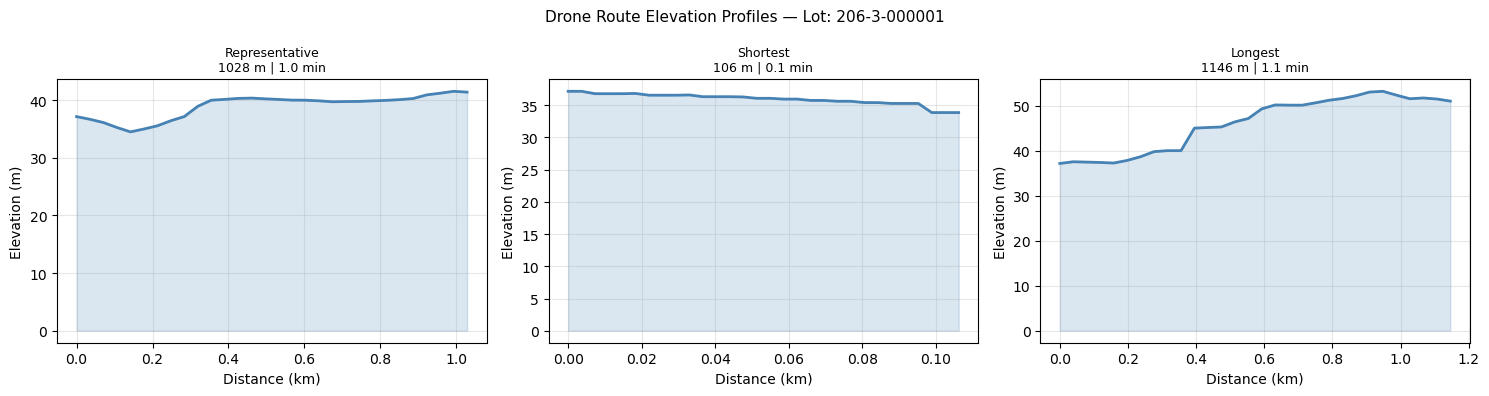

✓ nb11_elevation_profiles.png saved


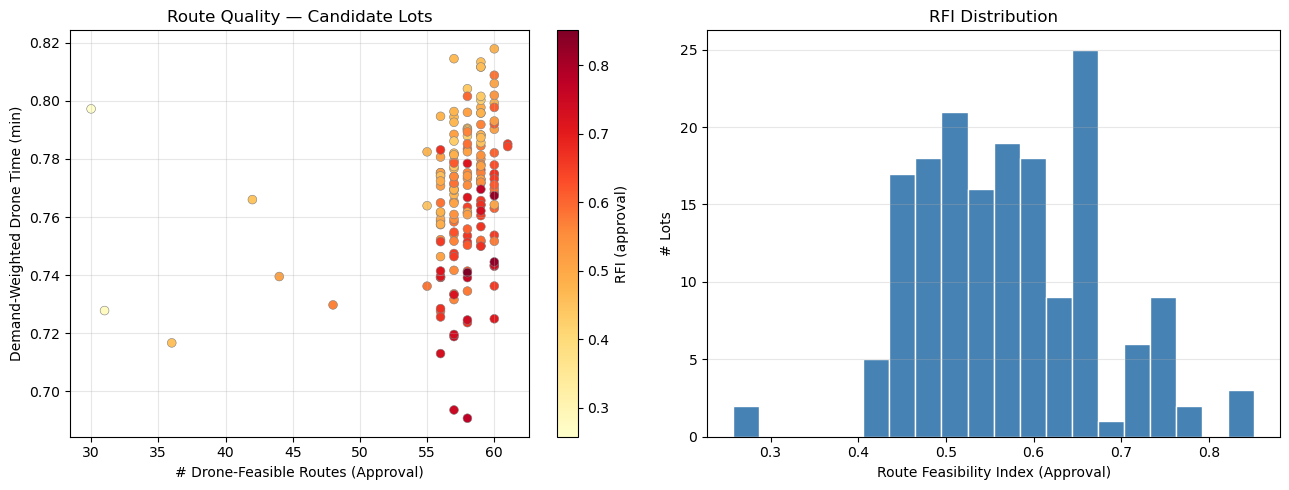

✓ nb11_route_diagnostics.png saved


In [13]:
# ── CELL 13 · Elevation Profiles & Diagnostics Chart ─────────────────────────

# ── 13a: Elevation profiles (3 representative routes from best-RFI lot) ───────
def _plot_elevation_profiles():
    if not HAS_DEM:
        print('⚠ No DEM — skipping elevation profiles')
        return
    best_lot = lot_summary.sort_values('route_feasibility_index_approval', ascending=False).iloc[0]['lot_id']
    cand = pairs[
        (pairs['lot_id'] == best_lot) &
        pairs['drone_direct_feasible_approval'] &
        pairs['drone_line'].notna()
    ]
    if len(cand) == 0:
        print('⚠ No feasible routes for best lot')
        return
    reps = [cand.iloc[0]]
    if len(cand) > 1:
        reps.append(cand.loc[cand['drone_distance_m'].idxmin()])
    if len(cand) > 2:
        reps.append(cand.loc[cand['drone_distance_m'].idxmax()])
    lbls = ['Representative', 'Shortest', 'Longest'][:len(reps)]

    fig, axes = plt.subplots(1, len(reps), figsize=(5 * len(reps), 4))
    if len(reps) == 1:
        axes = [axes]
    with rasterio.open(DEM_PATH) as src:
        for ax, r, lbl in zip(axes, reps, lbls):
            line  = r['drone_line']
            dists = np.linspace(0, line.length, ROUTE_SAMPLE_PTS)
            pts   = [(line.interpolate(d).x, line.interpolate(d).y) for d in dists]
            elevs = np.array([v[0] for v in src.sample(pts)], dtype=float)
            nd = src.nodata
            if nd is not None:
                elevs[elevs == nd] = np.nan
            km = dists / 1000
            ax.plot(km, elevs, color='steelblue', lw=2)
            ax.fill_between(km, elevs, alpha=0.2, color='steelblue')
            ax.set_title(f'{lbl}\n{line.length:.0f} m | {r["drone_time_min"]:.1f} min', fontsize=9)
            ax.set_xlabel('Distance (km)')
            ax.set_ylabel('Elevation (m)')
            ax.grid(alpha=0.3)
    fig.suptitle(f'Drone Route Elevation Profiles — Lot: {best_lot}', fontsize=11)
    plt.tight_layout()
    plt.savefig(PROC / 'nb11_elevation_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ nb11_elevation_profiles.png saved')

_plot_elevation_profiles()

# ── 13b: RFI scatter + distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(
    lot_summary['drone_feasible_approval_count'],
    lot_summary['demand_weighted_drone_time_min'].fillna(999),
    c=lot_summary['route_feasibility_index_approval'], cmap='YlOrRd',
    s=40, edgecolors='grey', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='RFI (approval)')
ax.set_xlabel('# Drone-Feasible Routes (Approval)')
ax.set_ylabel('Demand-Weighted Drone Time (min)')
ax.set_title('Route Quality — Candidate Lots')
ax.grid(alpha=0.3)

axes[1].hist(lot_summary['route_feasibility_index_approval'], bins=20,
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('Route Feasibility Index (Approval)')
axes[1].set_ylabel('# Lots')
axes[1].set_title('RFI Distribution')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PROC / 'nb11_route_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ nb11_route_diagnostics.png saved')


In [14]:
# ── CELL 14 · Save All Outputs ────────────────────────────────────────────────

OUTPUT_COLS = [
    'lot_id', 'lot_name', 'site_ADM_NM', 'site_GU_NM', 'site_CSV_ADMI_CD',
    'candidate_rank', 'candidate_grade', 'candidate_score_for_ranking',
    'target_h3_index', 'target_ADM_NM', 'target_GU_NM',
    'Ds', 'demand_grade', 'delivery_zone', 'service_priority_score', 'constraint_score',
    'score_airspace', 'score_obstacle', 'score_terrain', 'score_robot', 'score_weather',
    'hard_exclusion_flag', 'n_highrise', 'weather_risk',
    'distance_to_lot_m', 'within_1km_centroid',
    'drone_distance_m', 'drone_time_min',
    'elev_min_m', 'elev_max_m', 'elev_gain_m', 'mean_slope_deg', 'max_slope_deg',
    'robot_path_found', 'robot_distance_m', 'robot_time_min', 'robot_time_min_adjusted',
    'drone_direct_feasible_approval', 'drone_direct_feasible_strict', 'robot_handoff_feasible',
    'airspace_approval_required', 'strict_airspace_excluded',
    'route_crosses_airspace_exclusion', 'route_crosses_non_airspace_hard_exclusion',
    'route_crosses_hard_exclusion',
    'route_crossed_h3_count', 'route_mean_constraint_score', 'route_min_constraint_score',
    'route_mean_drone_score', 'route_mean_robot_score',
    'route_highrise_cell_count', 'route_max_weather_risk',
]
out_cols = [c for c in OUTPUT_COLS if c in pairs.columns]
missing  = [c for c in OUTPUT_COLS if c not in pairs.columns]
if missing:
    print(f'  ⚠ Missing output columns (will be absent from CSV): {missing}')

pairs_out = pairs[out_cols].copy()

# ① nb11_route_pairs.csv
pairs_out.to_csv(PROC / 'nb11_route_pairs.csv', index=False, encoding='utf-8-sig')
print(f'✓ nb11_route_pairs.csv — {len(pairs_out):,} rows × {len(out_cols)} cols')

# ② nb11_route_analysis.gpkg — drone_routes layer
vm = pairs['drone_line'].notna()
drone_gdf = gpd.GeoDataFrame(
    pairs_out[vm].copy(), geometry=pairs.loc[vm, 'drone_line'].values, crs=CRS_PROJ
)
drone_gdf.to_file(PROC / 'nb11_route_analysis.gpkg', layer='drone_routes', driver='GPKG')
print(f'✓ nb11_route_analysis.gpkg [drone_routes] — {len(drone_gdf):,} rows')

# candidate_points layer
cpt = sites_raw[['lot_id', 'lot_name', 'geometry']].merge(
    lot_summary[['lot_id', 'route_feasibility_index_approval', 'route_feasibility_index_strict',
                 'candidate_rank', 'candidate_grade', 'drone_feasible_approval_count',
                 'drone_feasible_strict_count', 'robot_handoff_feasible_count',
                 'served_Ds_sum_approval', 'site_ADM_NM', 'site_GU_NM', 'nb11_route_note']],
    on='lot_id', how='left'
)
cpt_gdf = gpd.GeoDataFrame(cpt, geometry='geometry', crs=sites_raw.crs).to_crs(CRS_PROJ)
cpt_gdf.to_file(PROC / 'nb11_route_analysis.gpkg', layer='candidate_points', driver='GPKG')
print(f'✓ nb11_route_analysis.gpkg [candidate_points] — {len(cpt_gdf)} rows')

# target_cells layer
target_set = set(pairs_out['target_h3_index'].unique())
tcells = zones_gdf[zones_gdf['h3_index'].isin(target_set)][
    ['h3_index', 'ADM_NM', 'GU_NM', 'Ds', 'demand_grade', 'delivery_zone', 'geometry']
].copy().to_crs(CRS_PROJ)
tcells.to_file(PROC / 'nb11_route_analysis.gpkg', layer='target_cells', driver='GPKG')
print(f'✓ nb11_route_analysis.gpkg [target_cells] — {len(tcells)} rows')

# ③ nb11_candidate_route_summary.csv
lot_summary.to_csv(PROC / 'nb11_candidate_route_summary.csv', index=False, encoding='utf-8-sig')
print(f'✓ nb11_candidate_route_summary.csv — {len(lot_summary)} lots')

# ④ nb11_route_map.html — saved in Cell 12
print(f'✓ nb11_route_map.html (written in Cell 12)')

# ⑤ nb11_route_diagnostics.json
diag = {
    'total_route_pairs':                    int(len(pairs_out)),
    'unique_lot_id_count':                  int(pairs_out['lot_id'].nunique()),
    'unique_target_h3_count':               int(pairs_out['target_h3_index'].nunique()),
    'site_ADM_NM_null_count':               int(pairs_out['site_ADM_NM'].isna().sum()) if 'site_ADM_NM' in pairs_out.columns else -1,
    'site_GU_NM_null_count':                int(pairs_out['site_GU_NM'].isna().sum())  if 'site_GU_NM'  in pairs_out.columns else -1,
    'drone_direct_feasible_approval':       int(pairs_out['drone_direct_feasible_approval'].sum()),
    'drone_direct_feasible_strict':         int(pairs_out['drone_direct_feasible_strict'].sum()),
    'robot_handoff_feasible':               int(pairs_out['robot_handoff_feasible'].sum()),
    'airspace_approval_required':           int(pairs_out['airspace_approval_required'].sum()),
    'route_crosses_airspace_exclusion':     int(pairs_out['route_crosses_airspace_exclusion'].sum()),
    'route_crosses_non_airspace_hard_exclusion': int(pairs_out['route_crosses_non_airspace_hard_exclusion'].sum()),
    'route_crosses_hard_exclusion':         int(pairs_out['route_crosses_hard_exclusion'].sum()),
    'valid_drone_geometries':               int(pairs['drone_line'].notna().sum()),
    'elev_min_m_non_null':                  int(pairs_out['elev_min_m'].notna().sum()) if 'elev_min_m' in pairs_out.columns else -1,
    'mean_slope_deg_non_null':              int(pairs_out['mean_slope_deg'].notna().sum()) if 'mean_slope_deg' in pairs_out.columns else -1,
    'route_mean_constraint_score_non_null': int(pairs_out['route_mean_constraint_score'].notna().sum()) if 'route_mean_constraint_score' in pairs_out.columns else -1,
    'rfi_approval_mean':                    float(lot_summary['route_feasibility_index_approval'].mean()),
    'rfi_approval_max':                     float(lot_summary['route_feasibility_index_approval'].max()),
    'rfi_strict_mean':                      float(lot_summary['route_feasibility_index_strict'].mean()),
    'network_used':                         USE_NETWORK,
    'has_dem':                              HAS_DEM,
    'has_slope':                            HAS_SLOPE,
    'has_airspace':                         HAS_AIRSPACE,
}
with open(PROC / 'nb11_route_diagnostics.json', 'w', encoding='utf-8') as f:
    json.dump(diag, f, indent=2, ensure_ascii=False)
print('✓ nb11_route_diagnostics.json')


✓ nb11_route_pairs.csv — 9,793 rows × 52 cols


✓ nb11_route_analysis.gpkg [drone_routes] — 9,793 rows
✓ nb11_route_analysis.gpkg [candidate_points] — 171 rows
✓ nb11_route_analysis.gpkg [target_cells] — 1106 rows
✓ nb11_candidate_route_summary.csv — 171 lots
✓ nb11_route_map.html (written in Cell 12)
✓ nb11_route_diagnostics.json


In [15]:
# ── CELL 15 · Final Validation ────────────────────────────────────────────────
print('=' * 65)
print('NB11 · FINAL VALIDATION')
print('=' * 65)

def _chk(label, val, expected=None, op='=='):
    if expected is None:
        print(f'  ℹ  {label}: {val}')
        return
    if op == '==' and val == expected:
        print(f'  ✓  {label}: {val}')
    elif op == '==' and val != expected:
        raise AssertionError(f'{label}: {val} ≠ {expected}')
    elif op == '<=' and val <= expected:
        print(f'  ✓  {label}: {val} ≤ {expected}')
    elif op == '<=' and val > expected:
        raise AssertionError(f'{label}: {val} > {expected}')
    elif op == '>=' and val >= expected:
        print(f'  ✓  {label}: {val} ≥ {expected}')

# ── Core counts ───────────────────────────────────────────────────────────────
_chk('route_pairs == coverage_rows', len(pairs_out), EXPECTED_N)
_chk('unique lot_id', pairs_out['lot_id'].nunique(), 171)

# ── Admin label nulls ─────────────────────────────────────────────────────────
_chk('site_ADM_NM null count', int(pairs_out['site_ADM_NM'].isna().sum()), 0)
_chk('site_GU_NM null count',  int(pairs_out['site_GU_NM'].isna().sum()),  0)
_chk('target_h3_index null count', int(pairs_out['target_h3_index'].isna().sum()), 0)

# ── Geometry ─────────────────────────────────────────────────────────────────
n_valid_geom = int(pairs['drone_line'].notna().sum())
_chk('valid drone geometries', n_valid_geom)

# ── DEM / slope ───────────────────────────────────────────────────────────────
nn_elev  = int(pairs_out['elev_min_m'].notna().sum())    if 'elev_min_m'     in pairs_out.columns else 0
nn_slope = int(pairs_out['mean_slope_deg'].notna().sum()) if 'mean_slope_deg' in pairs_out.columns else 0
_chk('elev_min_m non-null',    nn_elev)
_chk('mean_slope_deg non-null', nn_slope)

# ── Constraint corridor ───────────────────────────────────────────────────────
nn_corr = int(pairs_out['route_mean_constraint_score'].notna().sum()) if 'route_mean_constraint_score' in pairs_out.columns else 0
_chk('route_mean_constraint_score non-null', nn_corr)

# ── Feasibility ───────────────────────────────────────────────────────────────
n_app = int(pairs_out['drone_direct_feasible_approval'].sum())
n_str = int(pairs_out['drone_direct_feasible_strict'].sum())
_chk('drone_direct_feasible_approval', n_app, 1, op='>=')
_chk('drone_direct_feasible_strict',   n_str)
_chk('strict ≤ approval', n_str, n_app, op='<=')
_chk('robot_handoff_feasible', int(pairs_out['robot_handoff_feasible'].sum()))

# ── Output files ──────────────────────────────────────────────────────────────
print('\nOutput file check:')
required_outputs = [
    'nb11_route_pairs.csv',
    'nb11_route_analysis.gpkg',
    'nb11_candidate_route_summary.csv',
    'nb11_route_map.html',
    'nb11_elevation_profiles.png',
    'nb11_route_diagnostics.json',
]
all_ok = True
for fn in required_outputs:
    p = PROC / fn
    if p.exists():
        print(f'  ✓  {fn}  ({p.stat().st_size / 1024:.1f} KB)')
    else:
        print(f'  ✗  {fn}  MISSING')
        all_ok = False

print('\n' + '=' * 65)
if all_ok:
    print('NB11 VALIDATION PASSED — ready for NB12')
else:
    print('NB11 VALIDATION FAILED — check missing files above')
print('=' * 65)


NB11 · FINAL VALIDATION
  ✓  route_pairs == coverage_rows: 9793
  ✓  unique lot_id: 171
  ✓  site_ADM_NM null count: 0
  ✓  site_GU_NM null count: 0
  ✓  target_h3_index null count: 0
  ℹ  valid drone geometries: 9793
  ℹ  elev_min_m non-null: 9793
  ℹ  mean_slope_deg non-null: 9793
  ℹ  route_mean_constraint_score non-null: 9793
  ✓  drone_direct_feasible_approval: 9793 ≥ 1
  ℹ  drone_direct_feasible_strict: 208
  ✓  strict ≤ approval: 208 ≤ 9793
  ℹ  robot_handoff_feasible: 9765

Output file check:
  ✓  nb11_route_pairs.csv  (5300.8 KB)
  ✓  nb11_route_analysis.gpkg  (5388.0 KB)
  ✓  nb11_candidate_route_summary.csv  (44.3 KB)
  ✓  nb11_route_map.html  (535.8 KB)
  ✓  nb11_elevation_profiles.png  (68.4 KB)
  ✓  nb11_route_diagnostics.json  (0.8 KB)

NB11 VALIDATION PASSED — ready for NB12
